<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_Two_Branch_vs_Three_Channel_Closure_Splitting_Test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECSM Paper 2 Notebook  
## Two-Branch versus Three-Channel Closure Splitting in ECSM

**Purpose:** test the companion claim from the triadic-branching bridge paper:

\[
P
ightarrow A+B
\]

versus

\[
P
ightarrow A+B+C_0
\]

where \(C_0\) is a neutral closure branch.

The notebook asks whether a neutral closure branch becomes dynamically favoured only in high-load saturated regimes where two-branch mirror splitting leaves unresolved closure/helicity cost.

This is a **minimal toy enumeration**, not a Standard Model derivation.


## Model idea

A saturated parent excitation \(P\) has:

- load \(L_P\)
- charge-like projection \(Q_P\)
- closure demand \(C_P\)
- helicity/handedness demand \(H_P\)

We compare:

\[
\Delta E_2 = E(A+B)-E(P)
\]

\[
\Delta E_3 = E(A+B+C_0)-E(P)
\]

The three-channel closure branch is favoured when:

\[
\Delta E_3 < \Delta E_2
\]

Prediction:

\[
L<L_1 \Rightarrow P	ext{ stable}
\]

\[
L_1<L<L_2 \Rightarrow P
ightarrow A+B
\]

\[
L>L_2 \Rightarrow P
ightarrow A+B+C_0
\]


In [1]:
# CELL 1 — IMPORTS AND OUTPUT DIRECTORY

import itertools
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUT = Path("ecsm_triadic_closure_split_test_out")
OUT.mkdir(exist_ok=True)

print("Output directory:", OUT.resolve())


Output directory: /content/ecsm_triadic_closure_split_test_out


In [2]:
# CELL 2 — CONFIGURATION AND PARAMETERS

# Load scan
L_values = np.linspace(0.0, 6.0, 301)

# Parent stability scale: parent becomes expensive as load grows
parent_capacity = 1.25
parent_load_power = 2.0
parent_base = 0.0

# Fragment costs
split_cost_per_fragment = 0.55

# Two-branch channel properties:
# A+B can carry charge/mirror load, but has limited closure/helicity capacity.
two_branch_load_capacity = 3.2
two_branch_closure_capacity = 1.6
two_branch_helicity_capacity = 1.5

# Three-channel properties:
# A+B+C0 costs one extra fragment, but has more closure/helicity capacity.
three_branch_load_capacity = 4.8
three_branch_closure_capacity = 3.6
three_branch_helicity_capacity = 3.8

# Penalty weights
rho_load = 0.75
lambda_closure = 1.15
mu_helicity = 0.95

# Mapping from total load L to closure/helicity demand.
# These exponents make closure/helicity demand relatively mild at low load and stronger at high load.
closure_exponent = 1.35
helicity_exponent = 1.20
closure_scale = 0.40
helicity_scale = 0.35

params = {
    "parent_capacity": parent_capacity,
    "parent_load_power": parent_load_power,
    "split_cost_per_fragment": split_cost_per_fragment,
    "two_branch_load_capacity": two_branch_load_capacity,
    "two_branch_closure_capacity": two_branch_closure_capacity,
    "two_branch_helicity_capacity": two_branch_helicity_capacity,
    "three_branch_load_capacity": three_branch_load_capacity,
    "three_branch_closure_capacity": three_branch_closure_capacity,
    "three_branch_helicity_capacity": three_branch_helicity_capacity,
    "rho_load": rho_load,
    "lambda_closure": lambda_closure,
    "mu_helicity": mu_helicity,
    "closure_exponent": closure_exponent,
    "helicity_exponent": helicity_exponent,
    "closure_scale": closure_scale,
    "helicity_scale": helicity_scale,
}

with open(OUT / "model_parameters.json", "w") as f:
    json.dump(params, f, indent=2)

params


{'parent_capacity': 1.25,
 'parent_load_power': 2.0,
 'split_cost_per_fragment': 0.55,
 'two_branch_load_capacity': 3.2,
 'two_branch_closure_capacity': 1.6,
 'two_branch_helicity_capacity': 1.5,
 'three_branch_load_capacity': 4.8,
 'three_branch_closure_capacity': 3.6,
 'three_branch_helicity_capacity': 3.8,
 'rho_load': 0.75,
 'lambda_closure': 1.15,
 'mu_helicity': 0.95,
 'closure_exponent': 1.35,
 'helicity_exponent': 1.2,
 'closure_scale': 0.4,
 'helicity_scale': 0.35}

## Energy definitions

The parent is stable at low load but increasingly strained:

\[
E_P(L)=E_0+\left(
rac{L}{L_{
m cap}}
ight)^2
\]

Each split has a fragment cost plus penalties for unresolved load, closure, and helicity.

For a split channel \(X\):

\[
E_X = sN_{
m fragments}
+

ho \max(0,L-L_X)^2
+
\lambda \max(0,C-C_X)^2
+
\mu \max(0,H-H_X)^2
\]

where:

\[
C(L)=c_0 L^{p_C}, \qquad H(L)=h_0 L^{p_H}.
\]


In [3]:
# CELL 3 — ENERGY FUNCTIONS

def closure_demand(L):
    return closure_scale * np.power(np.maximum(L, 0), closure_exponent)

def helicity_demand(L):
    return helicity_scale * np.power(np.maximum(L, 0), helicity_exponent)

def parent_energy(L):
    return parent_base + np.power(np.maximum(L, 0) / parent_capacity, parent_load_power)

def channel_energy(L, n_fragments, load_capacity, closure_capacity, helicity_capacity):
    C = closure_demand(L)
    H = helicity_demand(L)

    load_penalty = rho_load * np.square(np.maximum(0, L - load_capacity))
    closure_penalty = lambda_closure * np.square(np.maximum(0, C - closure_capacity))
    helicity_penalty = mu_helicity * np.square(np.maximum(0, H - helicity_capacity))

    return (
        split_cost_per_fragment * n_fragments
        + load_penalty
        + closure_penalty
        + helicity_penalty
    )

def two_branch_energy(L):
    return channel_energy(
        L,
        n_fragments=2,
        load_capacity=two_branch_load_capacity,
        closure_capacity=two_branch_closure_capacity,
        helicity_capacity=two_branch_helicity_capacity,
    )

def three_branch_energy(L):
    return channel_energy(
        L,
        n_fragments=3,
        load_capacity=three_branch_load_capacity,
        closure_capacity=three_branch_closure_capacity,
        helicity_capacity=three_branch_helicity_capacity,
    )

# Quick sanity check at a few loads
for L in [0, 1, 2, 3, 4, 5, 6]:
    print(
        f"L={L:.1f} | E_parent={parent_energy(L):.3f} | "
        f"E_2={two_branch_energy(L):.3f} | E_3={three_branch_energy(L):.3f}"
    )


L=0.0 | E_parent=0.000 | E_2=1.100 | E_3=1.650
L=1.0 | E_parent=0.640 | E_2=1.100 | E_3=1.650
L=2.0 | E_parent=2.560 | E_2=1.100 | E_3=1.650
L=3.0 | E_parent=5.760 | E_2=1.130 | E_3=1.650
L=4.0 | E_parent=10.240 | E_2=2.843 | E_3=1.650
L=5.0 | E_parent=16.000 | E_2=8.533 | E_3=1.680
L=6.0 | E_parent=23.040 | E_2=18.759 | E_3=3.648


In [4]:
# CELL 4 — LOAD SCAN

rows = []
for L in L_values:
    Ep = parent_energy(L)
    E2 = two_branch_energy(L)
    E3 = three_branch_energy(L)

    energies = {
        "stable_parent": Ep,
        "two_branch_AB": E2,
        "three_channel_ABC0": E3,
    }
    winner = min(energies, key=energies.get)

    rows.append({
        "L": L,
        "closure_demand": closure_demand(L),
        "helicity_demand": helicity_demand(L),
        "E_parent": Ep,
        "E_two_branch": E2,
        "E_three_channel": E3,
        "DeltaE_2_vs_parent": E2 - Ep,
        "DeltaE_3_vs_parent": E3 - Ep,
        "DeltaE_3_minus_DeltaE_2": (E3 - Ep) - (E2 - Ep),
        "winner": winner,
    })

df = pd.DataFrame(rows)
df.to_csv(OUT / "triadic_closure_load_scan.csv", index=False)

df.head(), df.tail()


(      L  closure_demand  helicity_demand  E_parent  E_two_branch  \
 0  0.00        0.000000         0.000000  0.000000           1.1   
 1  0.02        0.002034         0.003201  0.000256           1.1   
 2  0.04        0.005186         0.007354  0.001024           1.1   
 3  0.06        0.008965         0.011963  0.002304           1.1   
 4  0.08        0.013220         0.016896  0.004096           1.1   
 
    E_three_channel  DeltaE_2_vs_parent  DeltaE_3_vs_parent  \
 0             1.65            1.100000            1.650000   
 1             1.65            1.099744            1.649744   
 2             1.65            1.098976            1.648976   
 3             1.65            1.097696            1.647696   
 4             1.65            1.095904            1.645904   
 
    DeltaE_3_minus_DeltaE_2         winner  
 0                     0.55  stable_parent  
 1                     0.55  stable_parent  
 2                     0.55  stable_parent  
 3                     0

In [5]:
# CELL 5 — FIND TRANSITION POINTS

def transition_points(df):
    transitions = []
    prev = df.iloc[0]["winner"]
    for _, row in df.iloc[1:].iterrows():
        cur = row["winner"]
        if cur != prev:
            transitions.append({
                "L": row["L"],
                "from": prev,
                "to": cur
            })
            prev = cur
    return pd.DataFrame(transitions)

transitions = transition_points(df)
transitions.to_csv(OUT / "triadic_closure_transitions.csv", index=False)

print(transitions if len(transitions) else "No transitions found.")


      L           from                  to
0  1.32  stable_parent       two_branch_AB
1  3.56  two_branch_AB  three_channel_ABC0


In [6]:
# CELL 6 — SUMMARY TABLE

summary = df.groupby("winner").agg(
    L_min=("L", "min"),
    L_max=("L", "max"),
    n_points=("L", "count"),
    mean_L=("L", "mean"),
    mean_E_parent=("E_parent", "mean"),
    mean_E_two_branch=("E_two_branch", "mean"),
    mean_E_three_channel=("E_three_channel", "mean"),
).reset_index()

summary.to_csv(OUT / "triadic_closure_winner_summary.csv", index=False)
summary


,winner,L_min,L_max,n_points,mean_L,mean_E_parent,mean_E_two_branch,mean_E_three_channel
0,stable_parent,0.00,1.30,66,0.65,0.363307,1.100000,1.650000
1,three_channel_ABC0,3.56,6.00,123,4.78,14.945707,8.025676,1.945142
2,two_branch_AB,1.32,3.54,112,2.43,4.046720,1.152665,1.650000


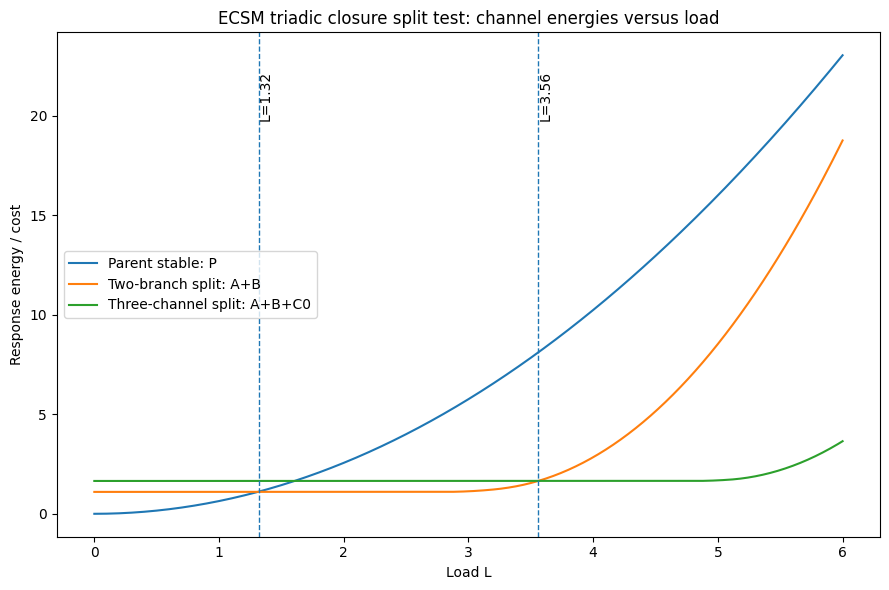

Saved: ecsm_triadic_closure_split_test_out/fig1_energy_curves.png


In [7]:
# CELL 7 — FIGURE 1: ENERGY CURVES

plt.figure(figsize=(9, 6))
plt.plot(df["L"], df["E_parent"], label="Parent stable: P")
plt.plot(df["L"], df["E_two_branch"], label="Two-branch split: A+B")
plt.plot(df["L"], df["E_three_channel"], label="Three-channel split: A+B+C0")

for _, row in transitions.iterrows():
    plt.axvline(row["L"], linestyle="--", linewidth=1)
    plt.text(row["L"], plt.ylim()[1] * 0.92, f"L={row['L']:.2f}", rotation=90, va="top")

plt.xlabel("Load L")
plt.ylabel("Response energy / cost")
plt.title("ECSM triadic closure split test: channel energies versus load")
plt.legend()
plt.tight_layout()

fig_path = OUT / "fig1_energy_curves.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("Saved:", fig_path)


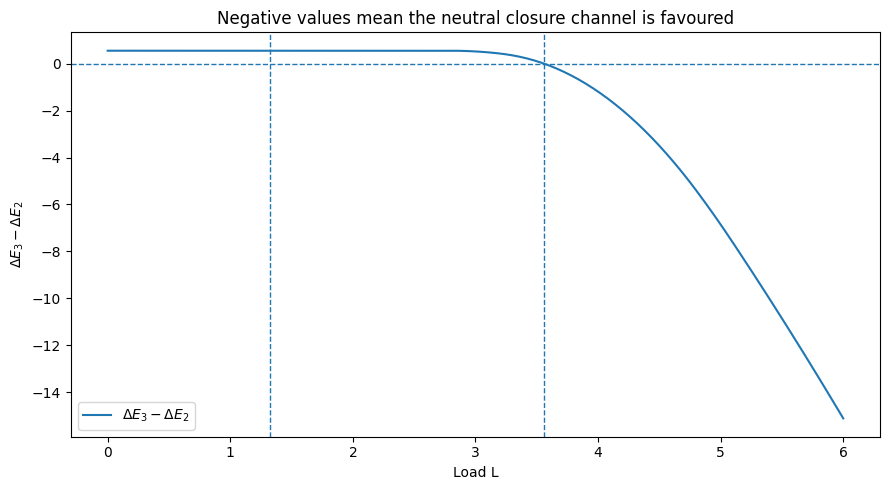

Saved: ecsm_triadic_closure_split_test_out/fig2_three_channel_advantage.png


In [8]:
# CELL 8 — FIGURE 2: THREE-CHANNEL ADVANTAGE

plt.figure(figsize=(9, 5))
plt.plot(df["L"], df["DeltaE_3_minus_DeltaE_2"], label=r"$\Delta E_3 - \Delta E_2$")
plt.axhline(0, linestyle="--", linewidth=1)

for _, row in transitions.iterrows():
    plt.axvline(row["L"], linestyle="--", linewidth=1)

plt.xlabel("Load L")
plt.ylabel(r"$\Delta E_3 - \Delta E_2$")
plt.title("Negative values mean the neutral closure channel is favoured")
plt.legend()
plt.tight_layout()

fig_path = OUT / "fig2_three_channel_advantage.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("Saved:", fig_path)


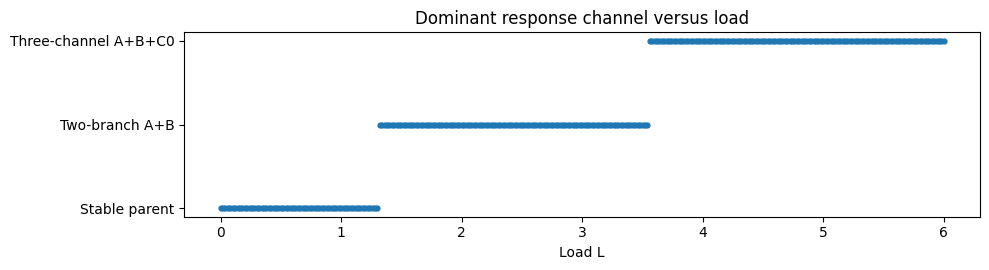

Saved: ecsm_triadic_closure_split_test_out/fig3_dominant_channel_map.png


In [9]:
# CELL 9 — FIGURE 3: DOMINANT CHANNEL MAP

# Convert winners to numeric codes for a compact regime map
winner_order = {
    "stable_parent": 0,
    "two_branch_AB": 1,
    "three_channel_ABC0": 2,
}
winner_labels = ["Stable parent", "Two-branch A+B", "Three-channel A+B+C0"]
codes = df["winner"].map(winner_order).to_numpy()

plt.figure(figsize=(10, 2.8))
plt.scatter(df["L"], codes, s=12)
plt.yticks([0, 1, 2], winner_labels)
plt.xlabel("Load L")
plt.title("Dominant response channel versus load")
plt.tight_layout()

fig_path = OUT / "fig3_dominant_channel_map.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("Saved:", fig_path)


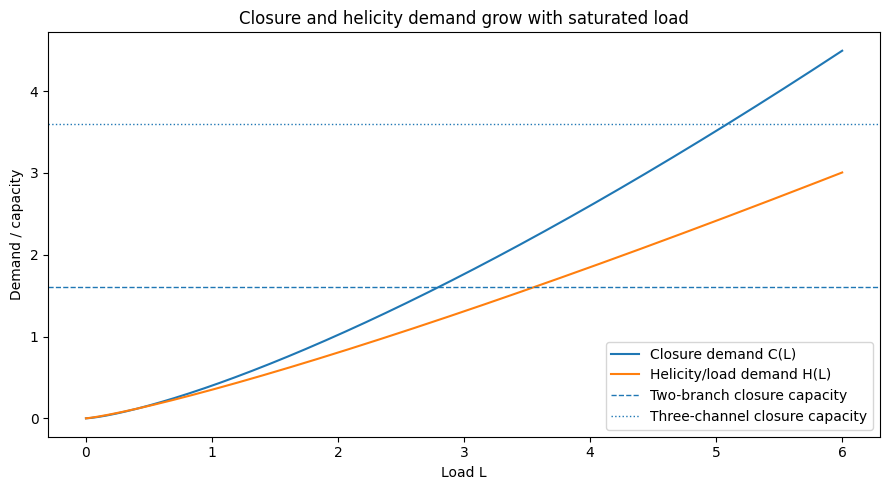

Saved: ecsm_triadic_closure_split_test_out/fig4_closure_helicity_demands.png


In [10]:
# CELL 10 — FIGURE 4: CLOSURE AND HELICITY DEMAND

plt.figure(figsize=(9, 5))
plt.plot(df["L"], df["closure_demand"], label="Closure demand C(L)")
plt.plot(df["L"], df["helicity_demand"], label="Helicity/load demand H(L)")

plt.axhline(two_branch_closure_capacity, linestyle="--", linewidth=1, label="Two-branch closure capacity")
plt.axhline(three_branch_closure_capacity, linestyle=":", linewidth=1, label="Three-channel closure capacity")

plt.xlabel("Load L")
plt.ylabel("Demand / capacity")
plt.title("Closure and helicity demand grow with saturated load")
plt.legend()
plt.tight_layout()

fig_path = OUT / "fig4_closure_helicity_demands.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("Saved:", fig_path)


## Interpretation checks

A good result for the paper is not merely that \(C_0\) can be made favourable.

The useful pattern is:

1. The parent remains stable at low load.
2. Two-branch splitting is favoured at intermediate load.
3. Three-channel splitting is favoured only at high load when closure/helicity demand exceeds what the mirror pair can carry.

That pattern supports:

\[
	ext{two branches}=	ext{polarity/mirror splitting}
\]

\[
	ext{three branches}=	ext{polarity plus closure}
\]


In [11]:
# CELL 11 — AUTOMATED VERDICT

observed_order = list(transitions["to"]) if len(transitions) else []
winners_seen = list(df["winner"].drop_duplicates())

expected_seen = ["stable_parent", "two_branch_AB", "three_channel_ABC0"]

verdict = {
    "winners_seen_in_order": winners_seen,
    "has_stable_parent": "stable_parent" in winners_seen,
    "has_two_branch_region": "two_branch_AB" in winners_seen,
    "has_three_channel_region": "three_channel_ABC0" in winners_seen,
    "has_all_three_regimes": all(w in winners_seen for w in expected_seen),
}

# Check whether three-channel appears only after two branch in load order
if verdict["has_all_three_regimes"]:
    first_L = {w: df.loc[df["winner"] == w, "L"].min() for w in expected_seen}
    verdict["ordered_regime_sequence"] = (
        first_L["stable_parent"] <= first_L["two_branch_AB"] <= first_L["three_channel_ABC0"]
    )
    verdict["first_L_by_winner"] = first_L
else:
    verdict["ordered_regime_sequence"] = False
    verdict["first_L_by_winner"] = {}

with open(OUT / "triadic_closure_verdict.json", "w") as f:
    json.dump(verdict, f, indent=2, default=float)

verdict


{'winners_seen_in_order': ['stable_parent',
  'two_branch_AB',
  'three_channel_ABC0'],
 'has_stable_parent': True,
 'has_two_branch_region': True,
 'has_three_channel_region': True,
 'has_all_three_regimes': True,
 'ordered_regime_sequence': True,
 'first_L_by_winner': {'stable_parent': 0.0,
  'two_branch_AB': 1.32,
  'three_channel_ABC0': 3.56}}

In [12]:
# CELL 12 — EXPORT PAPER-GRADE TABLES

# Compact transition table
if len(transitions):
    display(transitions)
else:
    print("No transitions found.")

# Representative rows around transitions
rep_rows = []
for L0 in [0, 1, 2, 3, 4, 5, 6]:
    idx = (df["L"] - L0).abs().idxmin()
    rep_rows.append(df.loc[idx])
rep = pd.DataFrame(rep_rows)

# Add rows near transition points
for _, tr in transitions.iterrows():
    idx = (df["L"] - tr["L"]).abs().idxmin()
    rep = pd.concat([rep, df.loc[[idx]]], ignore_index=True)

rep = rep.sort_values("L").drop_duplicates(subset=["L"])
rep.to_csv(OUT / "triadic_closure_representative_rows.csv", index=False)

rep[[
    "L",
    "E_parent",
    "E_two_branch",
    "E_three_channel",
    "DeltaE_2_vs_parent",
    "DeltaE_3_vs_parent",
    "DeltaE_3_minus_DeltaE_2",
    "winner"
]]


,L,from,to
0,1.32,stable_parent,two_branch_AB
1,3.56,two_branch_AB,three_channel_ABC0


,L,E_parent,E_two_branch,E_three_channel,DeltaE_2_vs_parent,DeltaE_3_vs_parent,DeltaE_3_minus_DeltaE_2,winner
0,0.00,0.000000,1.100000,1.650000,1.100000,1.650000,0.550000,stable_parent
1,1.00,0.640000,1.100000,1.650000,0.460000,1.010000,0.550000,stable_parent
7,1.32,1.115136,1.100000,1.650000,-0.015136,0.534864,0.550000,two_branch_AB
2,2.00,2.560000,1.100000,1.650000,-1.460000,-0.910000,0.550000,two_branch_AB
3,3.00,5.760000,1.130435,1.650000,-4.629565,-4.110000,0.519565,two_branch_AB
8,3.56,8.111104,1.651181,1.650000,-6.459923,-6.461104,-0.001181,three_channel_ABC0
4,4.00,10.240000,2.842772,1.650000,-7.397228,-8.590000,-1.192772,three_channel_ABC0
5,5.00,16.000000,8.532738,1.680000,-7.467262,-14.320000,-6.852738,three_channel_ABC0
6,6.00,23.040000,18.758652,3.647656,-4.281348,-19.392344,-15.110995,three_channel_ABC0


## Paper-ready result sentence template

Use only after checking the output:

> In the minimal response-functional scan, the selected channel changes with increasing saturated load. At low load the parent state remains stable; at intermediate load the two-branch mirror split is favoured; and at high load the three-channel configuration \(A+B+C_0\) becomes lowest-cost. This supports the triadic closure hypothesis: the neutral branch is selected not as an arbitrary extra component, but when unresolved closure/helicity load makes a two-branch split insufficient.


In [13]:
# CELL 13 — SAVE README FOR OUTPUT FOLDER

readme = f"""# ECSM Triadic Closure Split Test

This output folder was generated by the notebook:
Two-Branch versus Three-Channel Closure Splitting in ECSM.

Files:
- model_parameters.json
- triadic_closure_load_scan.csv
- triadic_closure_transitions.csv
- triadic_closure_winner_summary.csv
- triadic_closure_representative_rows.csv
- triadic_closure_verdict.json
- fig1_energy_curves.png
- fig2_three_channel_advantage.png
- fig3_dominant_channel_map.png
- fig4_closure_helicity_demands.png

Purpose:
Compare P -> A+B against P -> A+B+C0 under a minimal response functional.

Key criterion:
DeltaE_3 < DeltaE_2 in high-load saturated regimes.
"""

(OUT / "README.md").write_text(readme)

print("Notebook outputs will be written to:", OUT.resolve())


Notebook outputs will be written to: /content/ecsm_triadic_closure_split_test_out
